In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import requests

# URL avec les spécifications (exemple)
api_url = "https://equipements.sports.gouv.fr/api/explore/v2.1/catalog/datasets/data-es/records?where=equip_type_name%20like%20%27Court%20de%20tennis%27&limit=100"

In [82]:
# A function that transforms a call of the api into a usable panda file 
def call_api(api_url):
    req = requests.get(api_url)
    wb = req.json()
    print(wb.keys())

    df = pd.DataFrame(wb['results'])
    return(df)

#Cette fonction mange directement le lien que sort l''interface de l'api donc pas besoin de le modifier, elle rend un panda directement
#Il sert à obtenir des tableaux plus grands sans la limite de 100
def call_csv(url):

    url = url.replace("records", "exports/csv")
    # Send a GET request to the URL
    response = requests.get(url)

# Ensure the request was successful (status code 200)
    if response.status_code == 200:
    # Save the content to a file
        with open('equipements_ile_de_france.csv', 'wb') as f:
            f.write(response.content)

    # Load the CSV into a pandas DataFrame
        df = pd.read_csv('equipements_ile_de_france.csv', delimiter=';')

    # Display the first few rows of the DataFrame
    else:
        print(f"Failed to retrieve CSV. Status code: {response.status_code}")
    return(df)

In [83]:
#Un lien pour obtenir le nombre d'infrastructures par département
api_url = "https://equipements.sports.gouv.fr/api/explore/v2.1/catalog/datasets/data-es/records?select=COUNT(inst_numero)&group_by=dep_nom&order_by=dep_code&limit=100"
tab = call_api(api_url)
tab

dict_keys(['results'])


,dep_nom,COUNT(inst_numero)
0,None,3
1,Ain,4118
2,Aisne,3691
3,Allier,2591
4,Alpes-Maritimes,3672
...,...,...
95,Tarn,2821
96,Tarn-et-Garonne,1694
97,Territoire de Belfort,865
98,Val-d'Oise,4014


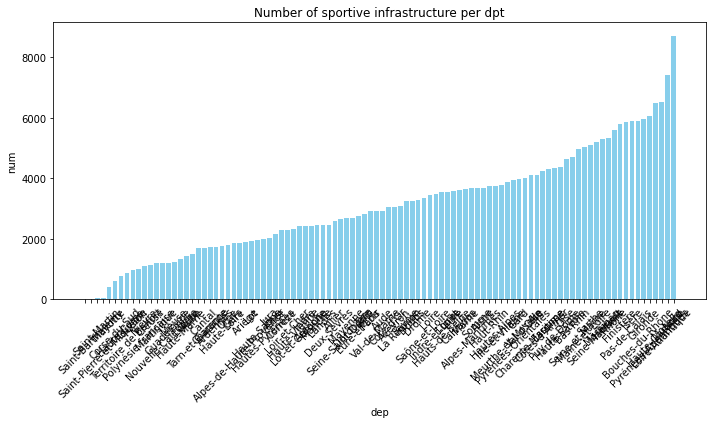

In [84]:
import numpy as np

#tab is the data from the previous call of the api (number of infrastructues per dpt)
tab = tab.sort_values(by='COUNT(inst_numero)', ascending=True)

y= tab['dep_nom']  # Sample data.

#fillna is to set NaN value to 0 so that plt.bar understands it
x = tab['COUNT(inst_numero)'].fillna(0)

# Note that even in the OO-style, we use `.pyplot.figure` to create the Figure.
plt.figure(figsize=(10, 6))

# Using range(len(x)) to plot bars for each department name
plt.bar(range(len(x)), x, color='skyblue')

# Labeling x-ticks with the department names
plt.xticks(range(len(x)), y, rotation=45)


plt.xlabel('dep')
plt.ylabel('num')
plt.title('Number of sportive infrastructure per dpt')

plt.tight_layout()       # Adjust layout for better appearance
plt.show()

In [85]:
# récupérer les superficies par département, sans les sites les plus grands (sites naturels et aménagés)

api_url = "https://equipements.sports.gouv.fr/api/explore/v2.1/catalog/datasets/data-es/records?select=dep_nom%2C%20equip_larg%2C%20equip_long%2C%20AVG(equip_larg*equip_long)%20as%20average_area&where=equip_larg%20is%20not%20null&group_by=dep_nom&order_by=dep_nom&limit=100"
api_url = "https://equipements.sports.gouv.fr/api/explore/v2.1/catalog/datasets/data-es/records?select=dep_nom%2C%20dep_code%2C%20AVG(equip_larg*equip_long)%20as%20average_area&where=equip_nature%20!%3D%20%22Site%20naturel%22%20AND%20equip_nature%20!%3D%20%22Site%20naturel%20am%C3%A9nag%C3%A9%22%20AND%20dep_code%20!%3D%20%2222%22&group_by=dep_nom%2C%20dep_code&limit=100""#61-Verbes de déplacement.mp3"
tab = call_api(api_url)
tab

dict_keys(['results'])


,dep_nom,dep_code,average_area
0,Ain,1,3651.728920
1,Aisne,2,9823.213794
2,Allier,3,2733.722505
3,Alpes-Maritimes,6,2316.528559
4,Alpes-de-Haute-Provence,4,4916.349885
...,...,...,...
95,Territoire de Belfort,90,1245.022136
96,Val-d'Oise,95,3570.391274
97,Val-de-Marne,94,1321.744778
98,Var,83,379322.677413


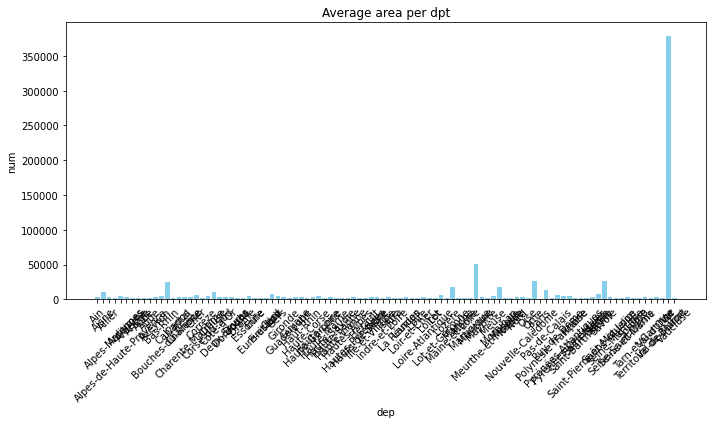

In [86]:
# Aire moyenne des infrastructures 

# tab = tab.sort_values(by='average_area', ascending=True)

y= tab['dep_nom']  # Sample data.

#fillna is to set NaN value to 0 so that plt.bar understands it
x = tab['average_area'].fillna(0)

# Note that even in the OO-style, we use `.pyplot.figure` to create the Figure.
plt.figure(figsize=(10, 6))

# Using range(len(x)) to plot bars for each department name
plt.bar(range(len(x)), x, color='skyblue')

# Labeling x-ticks with the department names
plt.xticks(range(len(x)), y, rotation=45)


plt.xlabel('dep')
plt.ylabel('num')
plt.title('Average area per dpt')

plt.tight_layout()       # Adjust layout for better appearance
plt.show()

In [87]:
#Exemple de récupération de données à partir d'une url de l'api, à noter que la spécification limit = -1 est très importante dans la fin du lien
api_url = "https://equipements.sports.gouv.fr/api/explore/v2.1/catalog/datasets/data-es/records?select=COUNT(inst_numero)&group_by=dep_code_filled&order_by=dep_code&limit=-1"
gym_data = call_csv(api_url)
#gym_data


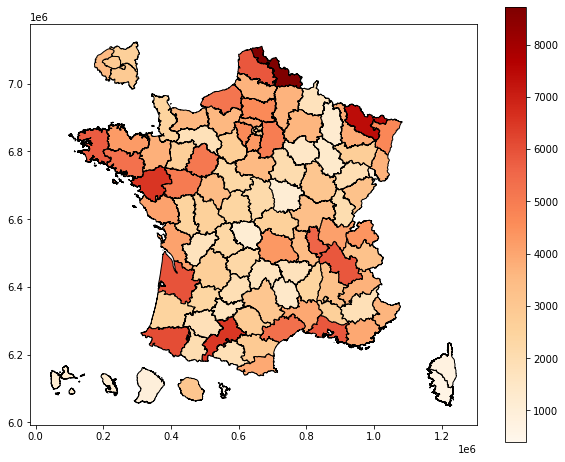

In [88]:
import geopandas as gpd
from cartiflette import carti_download

departements = carti_download(
    values="France",
    crs=4326,
    borders="DEPARTEMENT",
    vectorfile_format="geojson",
    filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022,
)

#Passage en espg 2154 : Lambert 93 pour avoir des surfaces en m²
departements = departements.to_crs(epsg=2154)

# Ajout de l'aire en km²
departements['AREA'] = departements.area.div(1e6)

#pour accorder les deux colonnes sur lesquelles merge les bases de donnée, la synthèse se fait sur 'dep_code_filled'
# Le filled est très important, il faudra donc ne pas omettre cette variable dans la requête API

departements['INSEE_DEP'] = departements['INSEE_DEP'].astype(str)
gym_data['dep_code_filled'] = gym_data['dep_code_filled'].astype(str)

#To correct duplicated departments in cartiflette, aggregation along the department code
departements = departements.dissolve(by='INSEE_DEP')
departements = departements.reset_index()
departements['INSEE_DEP'] = departements['INSEE_DEP'].astype(str)

#To merge cartiflette data and the database imported
departements = departements.merge(gym_data, left_on="INSEE_DEP", right_on="dep_code_filled", how="left")

ax = departements.plot(
    column='COUNT(inst_numero)',            # La colonne utilisée pour colorier la carte
    cmap='OrRd',                  # Palette de couleurs (Orange-Red)
    legend=True,                  # Afficher une légende
    figsize=(10, 8),              # Taille de la carte
    edgecolor='black'             # Couleur des bordures
)


In [89]:
#Importation de données économiques depuis : https://statistiques-locales.insee.fr/#c=indicator&i=filosofi.rd&s=2021&view=map2 (INSEE)

data_eco = pd.read_csv('C:/Users/cypri/OneDrive/Documents/Data/donnes_eco.csv', delimiter=';')
print(data_eco.head())
print(departements.columns)
#To merge cartiflette data and the database imported
departements = departements.merge(data_eco, left_on="INSEE_DEP", right_on="Code", how="left")



  Code                  Libelle Mediane du niveau de vie 2021  \
0   01                      Ain                         24810   
1   02                    Aisne                         20920   
2   03                   Allier                         21500   
3   04  Alpes-de-Haute-Provence                         21790   
4   05             Hautes-Alpes                         22010   

  Rapport interdecile du niveau de vie (9e déc./1er déc.) 2021  
0                                                3.5            
1                                                3.1            
2                                                  3            
3                                                3.2            
4                                                  3            
Index(['INSEE_DEP', 'geometry', 'PAYS', 'LIBELLE_DEPARTEMENT', 'POPULATION',
       'SOURCE', 'AREA', 'dep_code_filled', 'COUNT(inst_numero)'],
      dtype='object')


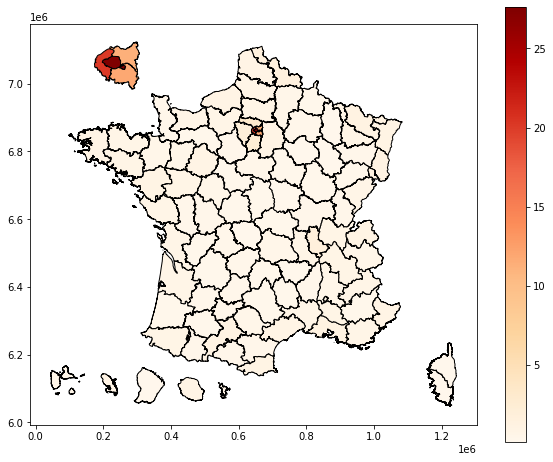

In [90]:
# Pour tracer un indice quelconque calculé à partir des valeurs de la grande matrice précédente ('departements'"Premier jet(1)(1).ipynb"
# Il suffit de changer le calcul dans la ligne suivante

departements['param_interet'] = departements['COUNT(inst_numero)']/departements['AREA']

ax = departements.plot(
    column='param_interet',            # La colonne utilisée pour colorier la carte
    cmap='OrRd',                  # Palette de couleurs (Orange-Red)
    legend=True,                  # Afficher une légende
    figsize=(10, 8),              # Taille de la carte
    edgecolor='black'             # Couleur des bordures
)

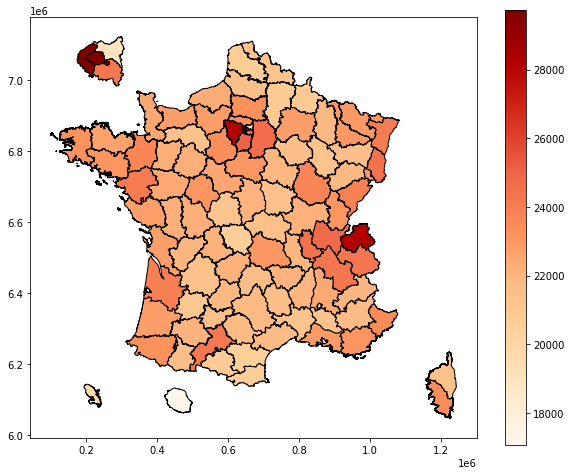

In [93]:
import copy

#Faire une copy pour ne pas enlever les départements dans le dataset initial
departements_local = copy.deepcopy(departements)

#Nettoyage de données : retirer les départements dont les données ne sont pas disponibles
departements_local['Mediane du niveau de vie 2021'] = departements_local['Mediane du niveau de vie 2021'].replace('N/A - résultat non disponible',np.nan).astype(float)
departements_local = departements_local.dropna(subset=['Mediane du niveau de vie 2021'])

ax = departements_local.plot(
    column='Mediane du niveau de vie 2021',            # La colonne utilisée pour colorier la carte
    cmap='OrRd',                  # Palette de couleurs (Orange-Red)
    legend=True,                  # Afficher une légende
    figsize=(10, 8),              # Taille de la carte
    edgecolor='black'             # Couleur des bordures
)




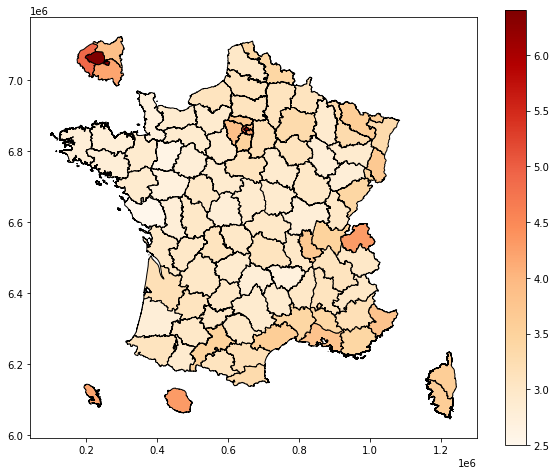

In [96]:
departements_local['Rapport interdecile du niveau de vie (9e déc./1er déc.) 2021'] = departements_local['Rapport interdecile du niveau de vie (9e déc./1er déc.) 2021'].astype(float)

# Rapport interdécile du niveau de vie (sorte de niveau d'inégalité)

ax = departements_local.plot(
    column='Rapport interdecile du niveau de vie (9e déc./1er déc.) 2021',            # La colonne utilisée pour colorier la carte
    cmap='OrRd',                  # Palette de couleurs (Orange-Red)
    legend=True,                  # Afficher une légende
    figsize=(10, 8),              # Taille de la carte
    edgecolor='black'             # Couleur des bordures
)

In [106]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

#Faire une régression linéaire
df = departements_local

# Sélectionner les colonnes pour la régression
X = df[['POPULATION', 'Rapport interdecile du niveau de vie (9e déc./1er déc.) 2021','AREA']]  # Variables indépendantes
y = df['COUNT(inst_numero)']            # Variable dépendante

# Initialiser le modèle de régression linéaire
model = LinearRegression()

# Entraîner le modèle
model.fit(X, y)

# Faire des prédictions
y_pred = model.predict(X)

# Afficher les coefficients
print("Coefficients de la régression :", model.coef_)
print("Ordonnée à l'origine (intercept) :", model.intercept_)

# Calculer l'erreur quadratique moyenne (RMSE)
rmse = np.sqrt(mean_squared_error(y, y_pred))
print("Erreur quadratique moyenne (RMSE) :", rmse)

#Calcul du R²
r2 = model.score(X, y)
print(f"R² : {r2}")

Coefficients de la régression : [ 2.91533916e-03 -6.60281322e+02  2.31884522e-01]
Ordonnée à l'origine (intercept) : 2176.978074542966
Erreur quadratique moyenne (RMSE) : 780.1431851416654
R² : 0.7509387412172583
